# Day 9: Image Classifier with Convolutional Neural Networks (CNN)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## 1. Load Data

In [6]:
url = "https://media.githubusercontent.com/media/Vvijayaragupathy-uno/machinelearning/main/day%20-%209%20/A_Z%20Handwritten%20Data.csv"

# The dataset has no header row, so we set header=None
# We download the ENTIRE dataset so we don't just get the letter A.
print("Downloading massive 700MB dataset (this will take a minute or two)...")
data = pd.read_csv(url, header=None)

# Grab a random mix of 10,000 letters so training is still fast
data = data.sample(10000, random_state=42)

print(data.head())

        0    1    2    3    4    5    6    7    8    9    ...  775  776  777  \
122926   13    0    0    0    0    0    0    0    0    0  ...    0    0    0   
270470   18    0    0    0    0    0    0    0    0    0  ...    0    0    0   
27001     2    0    0    0    0    0    0    0    0    0  ...    0    0    0   
115006   12    0    0    0    0    0    0    0    0    0  ...    0    0    0   
4997      0    0    0    0    0    0    0    0    0    0  ...    0    0    0   

        778  779  780  781  782  783  784  
122926    0    0    0    0    0    0    0  
270470    0    0    0    0    0    0    0  
27001     0    0    0    0    0    0    0  
115006    0    0    0    0    0    0    0  
4997      0    0    0    0    0    0    0  

[5 rows x 785 columns]


## 2. Understanding the Data (EDA)

Data Shape:
(10000, 785)

Missing Values: 0


/tmp/ipykernel_1925/2675569359.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[0], palette='viridis')


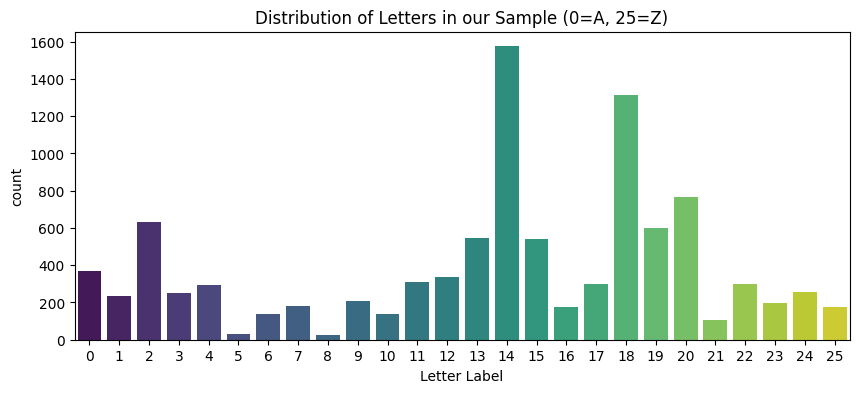

In [7]:
# Check the shape of the data
print("Data Shape:")
print(data.shape)
# Notice it has 785 columns! 
# Column 0 is the label (the letter). 
# Columns 1 to 784 are the pixel values for a 28x28 image (28 * 28 = 784).

# Check for missing values (None expected)
print("\nMissing Values:", data.isnull().sum().sum())

# Let's see the distribution of labels in our sample
# Labels are 0 to 25 representing A to Z
plt.figure(figsize=(10, 4))
sns.countplot(x=data[0], palette='viridis')
plt.title("Distribution of Letters in our Sample (0=A, 25=Z)")
plt.xlabel("Letter Label")
plt.show()

## 3. Data Preprocessing (Reshape & Normalize)

In [8]:
# 1. Separate the label (Column 0) from the pixels (Columns 1 to 784)
y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values

# 2. Reshape the flat 784 pixels into a 28x28x1 image grid
# -1 means "figure out how many images there are automatically"
# 28, 28 are the height and width
# 1 means grayscale (1 color channel). If it were color, it would be 3 (RGB).
X_reshaped = X.reshape(-1, 28, 28, 1)

# 3. Normalize the pixel values
# Pixels range from 0 (black) to 255 (white). 
# Neural networks prefer small numbers, so we divide by 255 to scale them between 0 and 1.
X_scaled = X_reshaped / 255.0

print("New shape of X:", X_scaled.shape)

New shape of X: (10000, 28, 28, 1)


## 4. Visualizing a Single Image

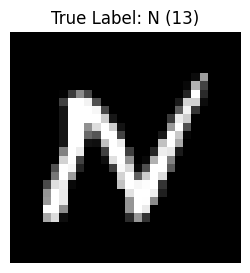

In [9]:
# Let's write a helper dictionary to map numbers (0-25) back to Letters (A-Z)
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
label_map = {i: letter for i, letter in enumerate(alphabet)}

# Plot the very first image in our dataset
plt.figure(figsize=(3, 3))
# We drop the last '1' dimension just for plotting purposes
plt.imshow(X_scaled[0].reshape(28, 28), cmap='gray')
plt.title(f"True Label: {label_map[y[0]]} ({y[0]})")
plt.axis('off')
plt.show()

## 5. Train / Test Split

In [10]:
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))

Training Images: 8000
Testing Images: 2000


## 6. Build the Convolutional Neural Network (CNN)

In [11]:
# CNNs are special neural networks designed specifically for Images!
model = models.Sequential([
    # 1st Convolutional Block: Scans the image for basic features (lines, edges)
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D(), # Shrinks the image to save memory and focus on the most important parts
    
    # 2nd Convolutional Block: Scans for more complex features (curves, shapes)
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    # Flatten: Flattens the 2D image map back into a 1D line of numbers
    layers.Flatten(),
    
    # Dense Layer: Traditional neural network layer to learn the combinations of features
    layers.Dense(64, activation="relu"),
    
    # Output Layer: 26 neurons for 26 letters in the alphabet. 
    # Softmax turns the output into percentage probabilities.
    layers.Dense(26, activation="softmax")
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,970 (480.35 KB)

 Trainable params: 122,970 (480.35 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the CNN

In [12]:
# Train for 5 epochs
history = model.fit(
    X_train, y_train, 
    epochs=5, 
    validation_data=(X_test, y_test)
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7085 - loss: 1.0598 - val_accuracy: 0.8760 - val_loss: 0.4087
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9091 - loss: 0.3048 - val_accuracy: 0.9190 - val_loss: 0.2718
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9429 - loss: 0.1918 - val_accuracy: 0.9380 - val_loss: 0.2070
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9596 - loss: 0.1365 - val_accuracy: 0.9395 - val_loss: 0.1967
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.1012 - val_accuracy: 0.9445 - val_loss: 0.1822


## 8. Evaluate the Model


Final Test Accuracy: 94.45%



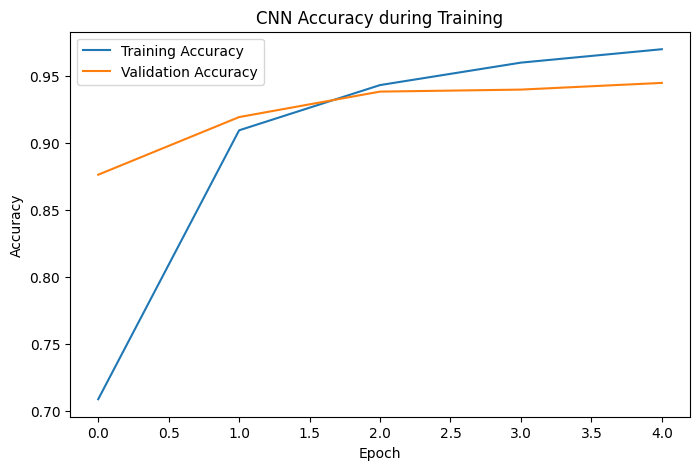

In [13]:
# Get the final test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%\n")

# Plot the training vs validation accuracy over time
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy during Training')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 9. Visualizing 5 Sample Predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


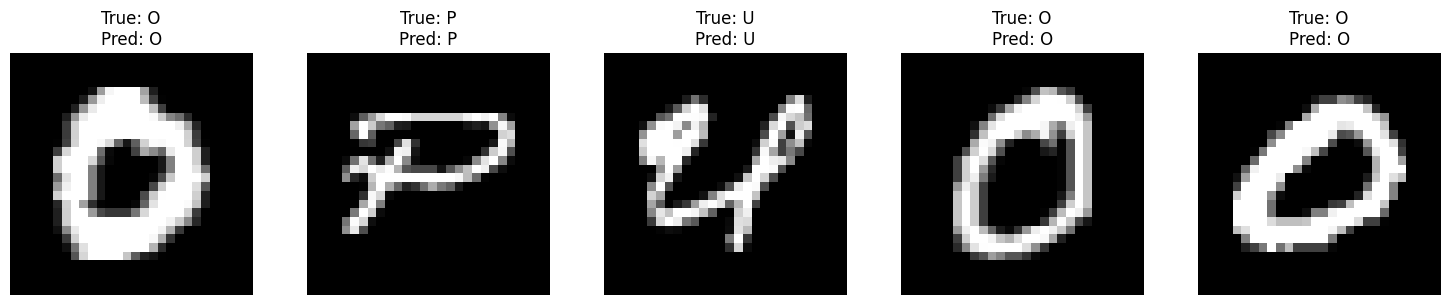

In [14]:
# Have the AI predict all test images
predictions = model.predict(X_test)

# Plot a grid of 5 sample images with their True vs Predicted labels
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # Get the raw image, true label, and the AI's predicted label (highest probability)
    img = X_test[i].reshape(28, 28)
    true_label = label_map[y_test[i]]
    predicted_label = label_map[np.argmax(predictions[i])]
    
    # Plot
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()